# Calibracion de hiperparametros con scikit-learn
### Pronostico de precio de combustible (Shell, Guatemala) — Proyecto1_Gasolineras

Este notebook cubre las etapas **4. Modeling** y **5. Evaluation** de **CRISP-DM**
aplicadas al dataset generado por el pipeline ETL del proyecto
(`Data/*.HEIC` -> bronze -> silver -> **gold / `db/gasolineras.db`**).

**Etapas previas de CRISP-DM** (ya resueltas por el pipeline, ver `README.md`):

1. **Business Understanding** — pronosticar `precio_galon` por combustible para decidir *cuanto y cuando comprar* inventario.
2. **Data Understanding** — EDA en `src/eda.py` / `reports/eda_report.md` (confianza de lectura, reconciliacion, tendencia, correlacion).
3. **Data Preparation** — `src/transform.py` (reconciliacion, imputacion, deteccion de atipicos) y `src/load.py` (dataset final `precios_combustible`).

Este notebook continua con:

4. **Modeling** — construir un `Pipeline` de scikit-learn (preprocesamiento + modelo) y calibrar
   hiperparametros de varios modelos con **validacion cruzada**.
5. **Evaluation** — comparar el error de los modelos calibrados y decidir si el resultado
   responde a la pregunta de negocio, dado el tamano de la muestra disponible.



In [1]:
import sqlite3
import warnings

import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils import estimator_html_repr

import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from src import config as C

# Diagrama HTML de los pipelines en vez de solo texto/repr
set_config(display="diagram")

print("scikit-learn listo.")


scikit-learn listo.


## 1. Carga de datos 


In [2]:
with sqlite3.connect(C.DB_PATH) as conn:
    df_raw = pd.read_sql("SELECT * FROM precios_combustible", conn)

print(df_raw.shape)
df_raw.head(8)


(20, 21)


,id,fecha,fecha_hora_local,anio,semana_iso,id_estacion,estacion,pais,latitud,longitud,...,tipo_combustible,categoria,precio_galon,precio_litro,moneda,calidad_precio,precio_galon_anterior,variacion_abs,variacion_pct,dias_desde_anterior
0,1,2026-07-09,2026-07-09 19:42:19,2026,28,ST_14p560_m90p463,Shell,Guatemala,14.560042,-90.462792,...,diesel,diesel,35.59,9.40,GTQ,imputado,NaN,NaN,NaN,NaN
1,2,2026-07-09,2026-07-09 19:42:19,2026,28,ST_14p560_m90p463,Shell,Guatemala,14.560042,-90.462792,...,regular,gasolina,37.09,9.80,GTQ,leido,NaN,NaN,NaN,NaN
2,3,2026-07-09,2026-07-09 19:42:19,2026,28,ST_14p560_m90p463,Shell,Guatemala,14.560042,-90.462792,...,super,gasolina,38.09,10.06,GTQ,reconciliado,NaN,NaN,NaN,NaN
3,4,2026-07-09,2026-07-09 19:42:19,2026,28,ST_14p560_m90p463,Shell,Guatemala,14.560042,-90.462792,...,v_power,gasolina,38.59,10.19,GTQ,leido,NaN,NaN,NaN,NaN
4,5,2026-07-15,2026-07-15 19:57:16,2026,29,ST_14p560_m90p463,Shell,Guatemala,14.560053,-90.462822,...,diesel,diesel,39.59,10.46,GTQ,imputado,35.59,4.00,11.24,6.0
5,6,2026-07-15,2026-07-15 19:57:16,2026,29,ST_14p560_m90p463,Shell,Guatemala,14.560053,-90.462822,...,regular,gasolina,38.47,10.16,GTQ,imputado,37.09,1.38,3.72,6.0
6,7,2026-07-15,2026-07-15 19:57:16,2026,29,ST_14p560_m90p463,Shell,Guatemala,14.560053,-90.462822,...,super,gasolina,39.59,10.46,GTQ,reconciliado,38.09,1.50,3.94,6.0
7,8,2026-07-15,2026-07-15 19:57:16,2026,29,ST_14p560_m90p463,Shell,Guatemala,14.560053,-90.462822,...,v_power,gasolina,40.09,10.59,GTQ,leido,38.59,1.50,3.89,6.0


## 2. Preparacion de features 

- **Target**: `precio_galon` (precio limpio, ya reconciliado/imputado en la etapa silver).
- **Features numericas**: `anio`, `semana_iso`, `dias_desde_anterior`, `precio_galon_anterior`
  (variable autorregresiva: el precio previo del mismo combustible).
- **Feature categorica**: `tipo_combustible` (diesel / regular / super / v_power).



In [3]:
NUMERIC_FEATURES = ["anio", "semana_iso", "dias_desde_anterior", "precio_galon_anterior"]
CATEGORICAL_FEATURES = ["tipo_combustible"]
TARGET = "precio_galon"

df = df_raw.dropna(subset=[TARGET, "precio_galon_anterior", "dias_desde_anterior"]).reset_index(drop=True)

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

print(f"Filas utilizables: {len(df)} de {len(df_raw)} totales")
X.head()


Filas utilizables: 16 de 20 totales


,anio,semana_iso,dias_desde_anterior,precio_galon_anterior,tipo_combustible
0,2026,29,6.0,35.59,diesel
1,2026,29,6.0,37.09,regular
2,2026,29,6.0,38.09,super
3,2026,29,6.0,38.59,v_power
4,2026,30,7.0,39.59,diesel


## 3. Investigacion: objetos de scikit-learn para armar y calibrar un pipeline

| Objeto | Para que sirve aqui |
|---|---|
| `ColumnTransformer` | Aplica una transformacion distinta por tipo de columna: `StandardScaler` a las numericas, `OneHotEncoder` a `tipo_combustible`. Evita tener que hacerlo a mano y mantiene el orden de columnas. |
| `Pipeline` | Encadena el preprocesamiento (`ColumnTransformer`) con el modelo final en **un solo objeto**. Es clave para evitar *data leakage*: el `StandardScaler`/`OneHotEncoder` se ajustan **solo** con el fold de entrenamiento en cada iteracion de la validacion cruzada, nunca con el fold de prueba. |
| `KFold` | Estrategia de validacion cruzada: parte los datos en *k* pliegues, entrena con *k-1* y evalua con el restante, rotando. Con tan pocos datos se usa un *k* pequeno. |
| `GridSearchCV` | Busqueda **exhaustiva**: prueba **todas** las combinaciones de un grid de hiperparametros, usando `KFold` internamente, y se queda con la de mejor score promedio. |
| `RandomizedSearchCV` | Alternativa quer muestrea *n* combinaciones al azar del espacio de hiperparametros en vez de probarlas todas. Util cuando el grid es grande y una busqueda exhaustiva es cara. Se ilustra abajo con `RandomForest`. |
| `cross_val_score` | Evalua un pipeline ya fijo (sin buscar hiperparametros) con validacion cruzada; se usa en la etapa de Evaluation para reconfirmar el mejor modelo. |

### 3.1 Armar el `Pipeline` y ver su diagrama



In [4]:
preprocesador = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

pipeline_demo = Pipeline([
    ("prep", preprocesador),
    ("model", Ridge()),
])

pipeline_demo  # al mostrarse, sklearn dibuja el diagrama (display="diagram")


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

In [5]:
diagram_path = C.FIGURES_DIR / "pipeline_diagram.html"
C.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
diagram_path.write_text(estimator_html_repr(pipeline_demo), encoding="utf-8")
print(f"Diagrama guardado en: {diagram_path}")


Diagrama guardado en: /Users/hugorivas/Documents/ML/Proyecto1_Gasolineras-/reports/figures/pipeline_diagram.html


## 4. Modeling (CRISP-DM) — calibracion de hiperparametros por modelo

Se calibra cada modelo dentro de su propio `Pipeline` (mismo preprocesador),
usando `GridSearchCV` con `KFold` y `neg_mean_absolute_error` como score.
Con solo unas pocas filas por combustible, `k` se limita a 4.


### 4.0 ¿Por qué esos hiperparámetros y no otros?

Los rangos de cada grid no son arbitrarios: se eligieron pensando en que solo hay
**16 filas utilizables** (riesgo alto de sobreajuste) y en el rol que cumple cada
hiperparámetro dentro de su modelo.

| Modelo | Hiperparámetro | Valores probados | Por qué ese rango |
|---|---|---|---|
| **Ridge** | `alpha` | `0.01, 0.1, 1.0, 10.0` | Barrido **logarítmico** de 3 órdenes de magnitud: cubre desde casi sin regularización hasta fuerte. Con pocos datos conviene tantear escalas amplias antes que valores finos — si el óptimo cae en un extremo, ahí se refinaría. |
| **Lasso** | `alpha` | `0.001, 0.01, 0.1, 1.0` | Rango corrido hacia abajo respecto a Ridge porque Lasso puede llevar coeficientes **exactamente a cero**. Con solo 4 features numéricas + la dummy de combustible, un `alpha` tan alto como 10 anularía casi todas las variables — no vale la pena probarlo. |
| **ElasticNet** | `alpha` | `0.001, 0.01, 0.1, 1.0` (igual que Lasso) | Mismo razonamiento que Lasso: el componente L1 de ElasticNet también puede anular coeficientes. |
| **ElasticNet** | `l1_ratio` | `0.2, 0.5, 0.8` | Interpola entre Ridge (`0`) y Lasso (`1`). Se usaron 3 puntos (mayormente-Ridge, balanceado, mayormente-Lasso) en vez de un barrido fino para no disparar el grid — ya son `4 × 3 = 12` combinaciones, razonable para `cv=4` con 16 filas. |
| **RandomForest** | `n_estimators` | `50, 100, 200` | Suficientes árboles para estabilizar el promedio del bosque; pasar de 300+ (típico en datasets grandes) no aporta nada aquí y solo aumenta el costo de cómputo. |
| **RandomForest** | `max_depth` | `None, 3, 5` | `None` sirve de referencia de sobreajuste (árboles crecen libres); `3` y `5` limitan la profundidad, que es lo sensato cuando cada árbol solo ve ~12 filas de entrenamiento por fold. |
| **GradientBoosting** | `n_estimators` | `50, 100` | El boosting se sobreajusta rápido en datasets chicos porque cada ronda suma error residual; se evitaron valores altos (300+) que sí tendrían sentido con más datos. |
| **GradientBoosting** | `learning_rate` | `0.05, 0.1` | Rango estándar de la literatura que compensa tener pocos estimadores con pasos moderados (ni tan chico que no converja, ni tan grande que oscile). |
| **GradientBoosting** | `max_depth` | `2, 3` | Árboles muy poco profundos (casi *stumps*): cada ronda de boosting ya agrega complejidad, así que los árboles base deben ser simples. |
| **KNN** | `n_neighbors` | `2, 3, 5` | Con `cv=4` sobre 16 filas, cada fold de entrenamiento tiene ~12 puntos. Un `k` grande (ej. 10) dejaría muy pocos vecinos "distintos" entre sí y suavizaría demasiado la predicción. |
| **KNN** | `weights` | `uniform, distance` | Compara voto parejo entre vecinos contra voto ponderado por cercanía — relevante porque el precio se mueve casi linealmente en el tiempo, así que el vecino más cercano en fecha debería pesar más. |




In [6]:
n_splits = min(4, len(df))
cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

if len(df) < 30:
    warnings.warn(
        f"Calibrando con solo {len(df)} filas: los resultados son orientativos, "
        "no concluyentes. Repetir cuando haya mas fotos/observaciones.",
        stacklevel=2,
    )

MODEL_GRIDS = {
    "Ridge": (Ridge(), {"model__alpha": [0.01, 0.1, 1.0, 10.0]}),
    "Lasso": (Lasso(max_iter=10000), {"model__alpha": [0.001, 0.01, 0.1, 1.0]}),
    "ElasticNet": (
        ElasticNet(max_iter=10000),
        {"model__alpha": [0.001, 0.01, 0.1, 1.0], "model__l1_ratio": [0.2, 0.5, 0.8]},
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"model__n_estimators": [50, 100, 200], "model__max_depth": [None, 3, 5]},
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
        },
    ),
    "KNN": (
        KNeighborsRegressor(),
        {"model__n_neighbors": [2, 3, 5], "model__weights": ["uniform", "distance"]},
    ),
}

resultados = []
mejores_pipelines = {}

for nombre, (estimador, grid) in MODEL_GRIDS.items():
    pipe = Pipeline([("prep", preprocesador), ("model", estimador)])
    busqueda = GridSearchCV(pipe, grid, cv=cv, scoring="neg_mean_absolute_error")
    busqueda.fit(X, y)
    mejores_pipelines[nombre] = busqueda.best_estimator_
    resultados.append({
        "modelo": nombre,
        "mae_cv": round(-busqueda.best_score_, 4),
        "mejores_params": {k.replace("model__", ""): v for k, v in busqueda.best_params_.items()},
    })

tabla_resultados = pd.DataFrame(resultados).sort_values("mae_cv").reset_index(drop=True)
tabla_resultados


/Users/hugorivas/Documents/ML/Proyecto1_Gasolineras-/.venv/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3775: UserWarning: Calibrando con solo 16 filas: los resultados son orientativos, no concluyentes. Repetir cuando haya mas fotos/observaciones.
  exec(code_obj, self.user_global_ns, self.user_ns)


,modelo,mae_cv,mejores_params
0,ElasticNet,0.5629,"{'alpha': 0.1, 'l1_ratio': 0.8}"
1,Lasso,0.5800,{'alpha': 0.1}
2,GradientBoosting,0.5807,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
3,Ridge,0.5920,{'alpha': 1.0}
4,RandomForest,0.6169,"{'max_depth': None, 'n_estimators': 200}"
5,KNN,0.6225,"{'n_neighbors': 2, 'weights': 'distance'}"


### 4.1 `RandomizedSearchCV` (alternativa a la busqueda exhaustiva)

Para `RandomForest` el espacio de hiperparametros puede crecer rapido. Aqui se
ilustra `RandomizedSearchCV`, que muestrea combinaciones al azar en vez de
probarlas todas — con `n_iter` combinaciones en vez de las `3 x 3 = 9` del grid
exhaustivo de arriba.


**Por qué ese espacio de búsqueda:**

- `n_estimators`: `randint(50, 300)` — rango más amplio que el grid exhaustivo de
  RandomForest de arriba (`50, 100, 200`). Como `RandomizedSearchCV` no evalúa
  *todas* las combinaciones, se puede permitir un rango más ancho sin disparar
  el costo de cómputo, y así explorar valores intermedios (ej. 137) que un grid
  fijo nunca probaría.
- `max_depth`: mismas opciones que el grid exhaustivo (`None, 2, 3, 4, 5`), para
  poder comparar directamente si el muestreo aleatorio encuentra algo mejor que
  la búsqueda exhaustiva con el mismo rango de profundidad.
- `min_samples_leaf`: `randint(1, 4)` — hiperparámetro adicional que **no** se
  incluyó en el grid exhaustivo (para no crecerlo más), pero que es clave para
  controlar el sobreajuste: obliga a que cada hoja del árbol tenga al menos esa
  cantidad de observaciones, evitando hojas de una sola fila con 16 datos.


In [7]:
from scipy.stats import randint

espacio_aleatorio = {
    "model__n_estimators": randint(50, 300),
    "model__max_depth": [None, 2, 3, 4, 5],
    "model__min_samples_leaf": randint(1, 4),
}

pipe_rf = Pipeline([("prep", preprocesador), ("model", RandomForestRegressor(random_state=42))])
busqueda_aleatoria = RandomizedSearchCV(
    pipe_rf, espacio_aleatorio, n_iter=8, cv=cv,
    scoring="neg_mean_absolute_error", random_state=42,
)
busqueda_aleatoria.fit(X, y)

print("Mejor MAE (RandomizedSearchCV, RandomForest):", round(-busqueda_aleatoria.best_score_, 4))
print("Mejores params:", busqueda_aleatoria.best_params_)


Mejor MAE (RandomizedSearchCV, RandomForest): 0.6225
Mejores params: {'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__n_estimators': 64}


## 5. Evaluation (CRISP-DM) — comparacion y lectura de resultados

Se reconfirma el mejor pipeline de cada modelo con `cross_val_score` (MAE y R2)
y se grafica la comparacion.


In [8]:
eval_rows = []
for nombre, pipe in mejores_pipelines.items():
    mae = -cross_val_score(pipe, X, y, cv=cv, scoring="neg_mean_absolute_error")
    r2 = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
    eval_rows.append({
        "modelo": nombre,
        "mae_promedio": round(mae.mean(), 4),
        "mae_std": round(mae.std(), 4),
        "r2_promedio": round(r2.mean(), 4),
    })

tabla_eval = pd.DataFrame(eval_rows).sort_values("mae_promedio").reset_index(drop=True)
tabla_eval


,modelo,mae_promedio,mae_std,r2_promedio
0,ElasticNet,0.5629,0.2200,0.4902
1,Lasso,0.5800,0.2176,0.4676
2,GradientBoosting,0.5807,0.2333,0.5321
3,Ridge,0.5920,0.1647,0.5184
4,RandomForest,0.6169,0.2079,0.5085
5,KNN,0.6225,0.1389,0.5309


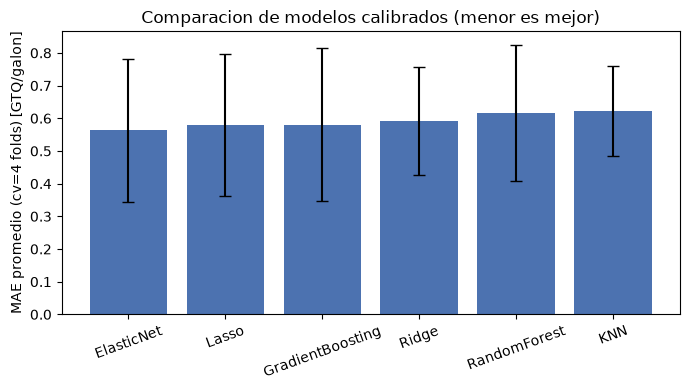

Figura guardada en: /Users/hugorivas/Documents/ML/Proyecto1_Gasolineras-/reports/figures/06_comparacion_modelos.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
orden = tabla_eval.sort_values("mae_promedio")
ax.bar(orden["modelo"], orden["mae_promedio"], yerr=orden["mae_std"], capsize=4, color="#4C72B0")
ax.set_ylabel(f"MAE promedio (cv={n_splits} folds) [{C.CURRENCY}/galon]")
ax.set_title("Comparacion de modelos calibrados (menor es mejor)")
plt.xticks(rotation=20)
plt.tight_layout()
out_path = C.FIGURES_DIR / "06_comparacion_modelos.png"
plt.savefig(out_path, dpi=130)
plt.show()
print(f"Figura guardada en: {out_path}")


## Capturas de pipeline empaquetado

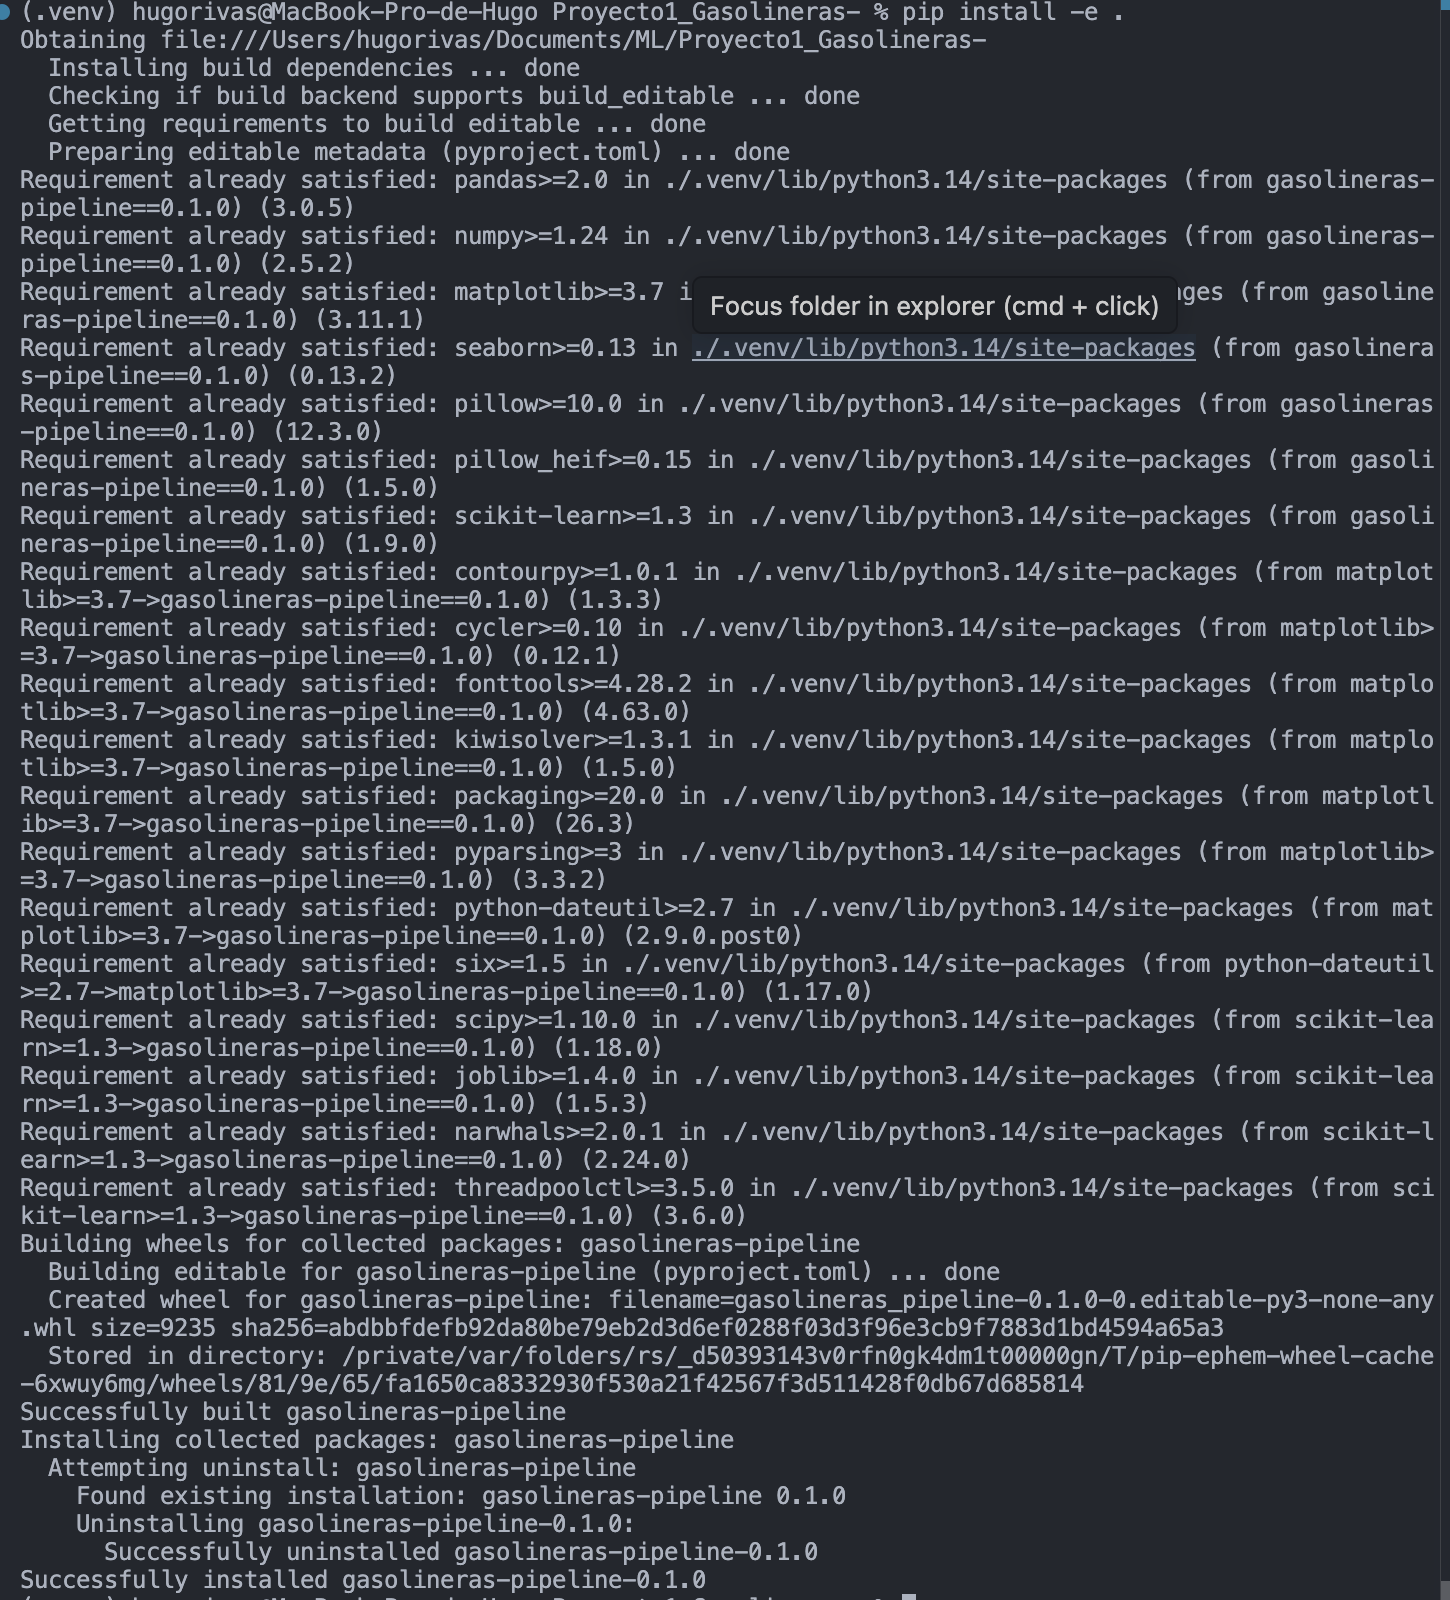

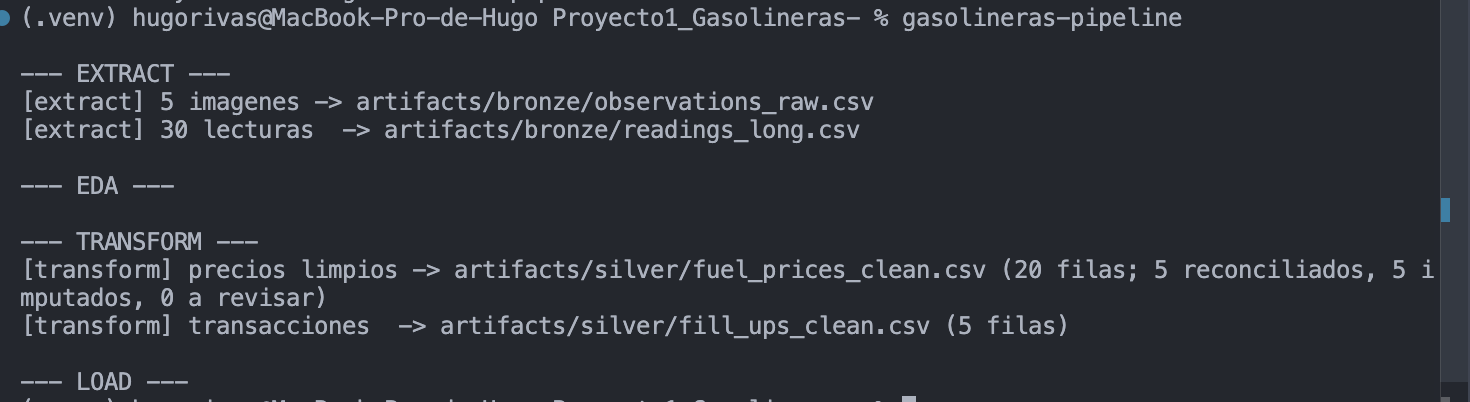